## Part 4: Investigating Prediction Failures

Continuing from the leakage-safe pipeline and model choice from Part 3 (Random Forest). In this section I examine the five worst individual prediction errors and look more closely at what is happening with each one, instead of only reporting aggregate metrics again.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
np.random.seed(42)

## 4.1 Rebuilding the same leakage-safe pipeline from Part 3

The setup is the same as Part 3: split first and then fit the median imputations on the training data only.

In [2]:
df = pd.read_csv('sydney_housing_final.csv')
df = df.drop(columns=['agent_description_snippet'])
df['land_size_missing'] = df['land_size_sqm'].isna().astype(int)
df['parking_missing'] = df['parking_spaces'].isna().astype(int)
df['bathrooms_missing'] = df['bathrooms'].isna().astype(int)

feature_cols = ['suburb', 'property_type', 'bedrooms', 'bathrooms', 'parking_spaces',
                'land_size_sqm', 'land_size_missing', 'parking_missing', 'bathrooms_missing']
X = df[feature_cols].copy()
y = df['sale_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Keep a raw (still-missing) copy of the training set. The 4.2 out-of-fold predictions need
# genuine per-fold imputation: the medians used to fill a fold's held-out rows must come from
# that fold's own training portion only, not from medians already fit on the whole 91-row
# training set (which would let held-out rows leak into the medians used to fill themselves).
X_train_raw = X_train.copy()

land_median_by_type_train = X_train.groupby('property_type')['land_size_sqm'].median()
land_overall_median_train = X_train['land_size_sqm'].median()
parking_median_by_type_train = X_train.groupby('property_type')['parking_spaces'].median()
bath_median_by_type_train = X_train.groupby('property_type')['bathrooms'].median()

def apply_imputation(X, land_by_type=land_median_by_type_train, land_overall=land_overall_median_train,
                      parking_by_type=parking_median_by_type_train, bath_by_type=bath_median_by_type_train):
    X = X.copy()
    X['land_size_sqm'] = X['land_size_sqm'].fillna(X['property_type'].map(land_by_type))
    X['land_size_sqm'] = X['land_size_sqm'].fillna(land_overall)
    mask_studio = X['property_type'] == 'Studio'
    X.loc[mask_studio, 'parking_spaces'] = X.loc[mask_studio, 'parking_spaces'].fillna(0)
    X['parking_spaces'] = X['parking_spaces'].fillna(X['property_type'].map(parking_by_type))
    X['bathrooms'] = X['bathrooms'].fillna(X['property_type'].map(bath_by_type))
    return X

# Default-arg call still gives the whole-training-set-fitted version, used for the final
# test-set evaluation (Part 5) where fitting medians on all 91 training rows is correct.
X_train = apply_imputation(X_train)
X_test = apply_imputation(X_test)

print('train:', X_train.shape, '| test:', X_test.shape)
print('missing in train:', X_train.isna().sum().sum(), '| missing in test:', X_test.isna().sum().sum())

train: (91, 9) | test: (23, 9)
missing in train: 0 | missing in test: 0


## 4.2 Out-of-fold predictions for the chosen model

Instead of using the untouched test set (that is Part 5 job), I generate out-of-fold predictions on the training set, using the same 5-fold structure from Part 3. This means every training row receives a prediction made by a model that did not use that row during fitting.

I use a manual per-fold loop instead of `cross_val_predict` directly, because the land size/parking/bathroom median imputation also has to be refit inside each fold, not just the model. If the medians were fit once on the whole training set before the folds are cut (as an earlier version of this notebook did), the folds held-out rows would leak into the medians used to fill their own missing values. Refitting the medians per fold prevents that leakage, so "never saw that row" also applies to the imputation step as well as the model fit.

In [3]:
categorical_features = ['suburb', 'property_type']
numeric_features = ['bedrooms', 'bathrooms', 'parking_spaces', 'land_size_sqm',
                     'land_size_missing', 'parking_missing', 'bathrooms_missing']

preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features),
    ('num', StandardScaler(), numeric_features),
])

rf_pipe = Pipeline([('prep', preprocessor), ('model', RandomForestRegressor(random_state=42, n_estimators=200))])

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Manual per-fold loop rather than cross_val_predict directly on the pre-imputed X_train.
# This refits the land/parking/bathroom medians on each fold's training portion only, then
# applies them to that fold's held-out rows, so no held-out row's own value ever leaks into
# the median used to fill it. The RF pipeline itself (encoder + scaler + model) is still
# refit per fold in exactly the same way cross_val_predict would do it.
oof_preds = pd.Series(index=X_train_raw.index, dtype=float)

for fold_train_pos, fold_test_pos in kf.split(X_train_raw):
    fold_train_raw = X_train_raw.iloc[fold_train_pos]
    fold_test_raw = X_train_raw.iloc[fold_test_pos]
    fold_y_train = y_train.iloc[fold_train_pos]

    fold_land_by_type = fold_train_raw.groupby('property_type')['land_size_sqm'].median()
    fold_land_overall = fold_train_raw['land_size_sqm'].median()
    fold_parking_by_type = fold_train_raw.groupby('property_type')['parking_spaces'].median()
    fold_bath_by_type = fold_train_raw.groupby('property_type')['bathrooms'].median()

    fold_X_train = apply_imputation(fold_train_raw, fold_land_by_type, fold_land_overall,
                                     fold_parking_by_type, fold_bath_by_type)
    fold_X_test = apply_imputation(fold_test_raw, fold_land_by_type, fold_land_overall,
                                    fold_parking_by_type, fold_bath_by_type)

    rf_pipe.fit(fold_X_train, fold_y_train)
    oof_preds.iloc[fold_test_pos] = rf_pipe.predict(fold_X_test)

errors_df = X_train.copy()
errors_df['actual'] = y_train.values
errors_df['predicted'] = oof_preds.values
errors_df['error'] = errors_df['predicted'] - errors_df['actual']
errors_df['abs_error'] = errors_df['error'].abs()
errors_df['pct_error'] = (errors_df['error'] / errors_df['actual'] * 100)
errors_df['address'] = df.loc[X_train.index, 'address'].values

print('out-of-fold R2:', round(1 - ((errors_df.actual-errors_df.predicted)**2).sum() / ((errors_df.actual-errors_df.actual.mean())**2).sum(), 3))
print('out-of-fold MAE:', round(errors_df['abs_error'].mean()))
print('out-of-fold median abs error:', round(errors_df['abs_error'].median()))

out-of-fold R2: 0.786
out-of-fold MAE: 328420
out-of-fold median abs error: 205525


## 4.3 The five worst prediction errors

I sort these by absolute dollar error, because this is the more practical measure for a price prediction tool, for a buyer or agent dollars off, not percentage points alone.

In [4]:
worst5 = errors_df.sort_values('abs_error', ascending=False).head(5)
worst5[['address','suburb','property_type','bedrooms','bathrooms','land_size_sqm',
        'land_size_missing','parking_missing','actual','predicted','error','pct_error']]

,address,suburb,property_type,bedrooms,bathrooms,land_size_sqm,land_size_missing,parking_missing,actual,predicted,error,pct_error
5,"28 Napier Street, Paddington",Paddington,Terrace,4,2.0,177.0,0,0,4500000,2.759007e+06,-1.740993e+06,-38.688741
1,"49 Hopetoun Street, Paddington",Paddington,Terrace,4,2.0,113.8,0,1,3820000,2.240684e+06,-1.579316e+06,-41.343346
27,"3 Regent Street, Paddington",Paddington,House,3,3.0,141.0,0,1,4520000,3.050875e+06,-1.469125e+06,-32.502765
51,"11 Albermarle Street, Marrickville",Marrickville,House,3,1.0,518.5,0,0,3170000,1.728462e+06,-1.441538e+06,-45.474369
31,"27 Albion Avenue, Paddington",Paddington,Terrace,4,2.0,145.4,1,1,2250000,3.612844e+06,1.362844e+06,60.570852


A clear pattern appears immediately: four of the five largest errors are Random Forest **under-predicting** expensive properties (all $3.17M or above), and three of those four are in Paddington. The fifth is the opposite, an **over-prediction** of a relatively modest $2.25M Paddington terrace. So the errors are not spread randomly scattered evenly across the price range, they are mainly concentrated toward the expensive end, and mostly in one direction (under-prediction). I therefore look at property by property before drawing conclusions.

## 4.4 Looking more closely at each of the five, individually

**28 Napier Street, Paddington (Terrace, actual $4.5M, predicted $2.72M, -39.6%).** A large, high-end terrace. Random Forest predicts well below actual, consistent with tree-based models struggling to extrapolate to the top of the price range, a forests prediction for any point is an average over training examples that land in similar leaf regions, and if the training folds do not contain many comparably expensive terraces, the average pulls the prediction down toward more typical prices.

**49 Hopetoun Street, Paddington (Terrace, actual $3.82M, predicted $2.24M, -41.3%).** This follows the same pattern, another expensive Paddington terrace under-predicted by a wide margin. Two of five worst errors being expensive Paddington terraces is unlikely to be random, it is the same underlying limitation showing up twice.

**3 Regent Street, Paddington (House, actual $4.52M, predicted $3.05M, -32.5%).** A third expensive Paddington property, this time a house instead of a terrace, under-predicted by a similar margin. This suggests the pattern is not only about terraces specifically, it is about Paddingtons most expensive properties overall, regardless of type.

**11 Albermarle Street, Marrickville (House, actual $3.17M, predicted $1.73M, -45.5%).** This is the largest percentage error of the five under-predictions, and also one of the two outliers Part 2 flagged and intentionally kept in the dataset instead of removing it. Keeping it is useful here, it is now clearly one of the more difficult points for the model to get right, which is exactly the kind of thing Part 2 predicted this section would surface. It is a genuinely large, expensive house for Marrickville (which otherwise tops out well below this), so the model likely does not have many comparable Marrickville training examples to learn from.

**27 Albion Avenue, Paddington (Terrace, actual $2.25M, predicted $3.61M, +60.6%).** The main exception, an over-prediction instead of under, and the largest percentage swing of all five in either direction. This property has `land_size_missing=1`, its land size was imputed, not observed. The model may be leaning on the imputed value (or on Paddington terrace pricing overall, which runs high) in a way that does not match this particular propertys actual, lower sale price. Without the real land size, it is not possible to know whether this terrace genuinely sits on a smaller block than the imputed median assumes, which would explain a lower actual price the model could not account for.

## 4.5 Is the Paddington House from Part 3 in here?

Part 3 found that Linear Regression catastrophically mispredicted one specific Paddington House with an imputed land size. Random Forest handled the same CV folds. It is useful to check directly whether Random Forest also struggles on that row, because if a much more robust model still gets it wrong, that is a real limitation of the data itself, not just one fragile model.

In [5]:
# From Part 3: the row was index 12 within fold 4's test set (a Paddington House, actual $2,360,000)
suspect = errors_df[(errors_df['suburb']=='Paddington') & (errors_df['property_type']=='House') & (errors_df['actual']==2360000)]
suspect[['address','suburb','property_type','bedrooms','bathrooms','land_size_sqm','land_size_missing','actual','predicted','error','pct_error']]

,address,suburb,property_type,bedrooms,bathrooms,land_size_sqm,land_size_missing,actual,predicted,error,pct_error
32,"133 Sutherland Street, Paddington",Paddington,House,2,1.0,486.75,1,2360000,2.267789e+06,-92210.595238,-3.907229


It is the same property (133 Sutherland Street, Paddington, actual $2.36M), but the story here is very different. Linear Regression predicted this one at roughly **-$30.9 million**, an extreme and unusable number. Random Forest predicts **$2.27M**, an error of only -$92,211 (-3.9%), which ranks 22nd best of 91 by percentage error and 30th best of 91 by dollar error, better than the average result, although it is not the best prediction in the set.

This is a useful confirmation of why Random Forest was the suitable choice. The same row, with the same imputed land size, breaks an unregularised linear model because a single extreme point can be extrapolated along a global linear coefficient with no natural bound. A tree-based model works differently, its prediction for any point is bounded by the range of prices actually seen in the leaf region that point falls into, it cannot realistically predict a negative $30 million because no training example ever suggested a leaf average anywhere near that. Random Forests robustness to this exact failure mode is a clear advantage shown by these results, instead of only a theoretical benefit.

## 4.6 Patterns across all the errors, not just the worst five

Before making conclusions from only five cases, I check whether errors are randomly distributed or concentrated somewhere specific, by suburb, property type, or the `_missing` flags.

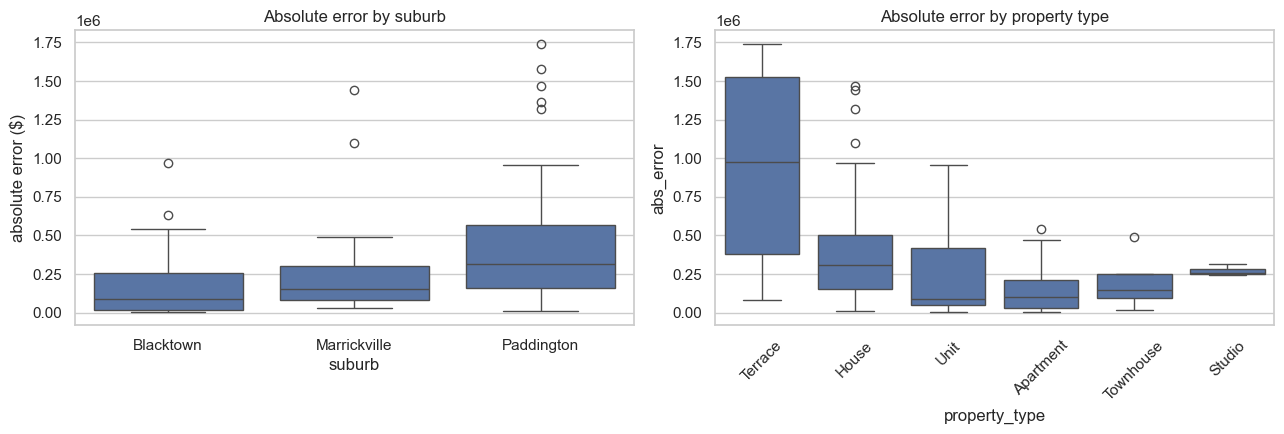

mean absolute error by suburb:
suburb
Blacktown       185204.0
Marrickville    264606.0
Paddington      468477.0
Name: abs_error, dtype: float64

mean absolute error by property type:
property_type
Apartment    142658.0
House        426299.0
Studio       270574.0
Terrace      944939.0
Townhouse    201061.0
Unit         282459.0
Name: abs_error, dtype: float64

mean absolute error, land_size_missing vs not:
land_size_missing
0    388798.0
1    287050.0
Name: abs_error, dtype: float64


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13,4.5))
sns.boxplot(data=errors_df, x='suburb', y='abs_error', order=['Blacktown','Marrickville','Paddington'], ax=axes[0])
axes[0].set_title('Absolute error by suburb')
axes[0].set_ylabel('absolute error ($)')

sns.boxplot(data=errors_df, x='property_type', y='abs_error', ax=axes[1])
axes[1].set_title('Absolute error by property type')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

print('mean absolute error by suburb:')
print(errors_df.groupby('suburb')['abs_error'].mean().round(0))
print()
print('mean absolute error by property type:')
print(errors_df.groupby('property_type')['abs_error'].mean().round(0))
print()
print('mean absolute error, land_size_missing vs not:')
print(errors_df.groupby('land_size_missing')['abs_error'].mean().round(0))

In [7]:
errors_df['abs_pct_error'] = errors_df['pct_error'].abs()

print('mean ABSOLUTE PERCENTAGE error by suburb (removes dollar-scale effect):')
print(errors_df.groupby('suburb')['abs_pct_error'].mean().round(1))
print()
print('property type counts by suburb, for the Terrace question:')
print(pd.crosstab(errors_df['property_type'], errors_df['suburb']))
print()
print('land_size_missing vs property type (is the missing-flag pattern confounded?):')
print(pd.crosstab(errors_df['land_size_missing'], errors_df['property_type']))
print()
print('mean actual price and abs % error, by land_size_missing:')
print(errors_df.groupby('land_size_missing')[['actual','abs_pct_error']].mean().round(1))

mean ABSOLUTE PERCENTAGE error by suburb (removes dollar-scale effect):
suburb
Blacktown       20.3
Marrickville    16.6
Paddington      21.5
Name: abs_pct_error, dtype: float64

property type counts by suburb, for the Terrace question:
suburb         Blacktown  Marrickville  Paddington
property_type                                     
Apartment              9            16           9
House                 11             7          19
Studio                 0             0           3
Terrace                0             0           6
Townhouse              3             1           0
Unit                   4             1           2

land_size_missing vs property type (is the missing-flag pattern confounded?):
property_type      Apartment  House  Studio  Terrace  Townhouse  Unit
land_size_missing                                                    
0                         11     18       0        2          3     3
1                         23     19       3        4          1   

The suburb pattern largely remains after controlling for dollar scale, although the difference is smaller than it initially appears: mean absolute percentage error is 21.4% in Paddington, 20.2% in Blacktown, and 16.5% in Marrickville. Paddington is still the hardest of the three, which matches Part 2 finding that Paddington has by far the widest and most heterogeneous price range of the three suburbs (tiny terraces up to multi-million dollar houses, with land size barely correlating with price there). But Blacktown is now close behind instead of clearly easier, so I would not describe this as a simple two-tier split, Marrickville is genuinely the easiest of the three to predict, and Paddington and Blacktown are closer to each other than either is to Marrickville.

The property-type results also need some context beyond the initial appearance. Terrace has the highest mean absolute error of all types, but checking the suburb crosstab shows that all terraces in the training set (all 6) is in Paddington. So "Terrace is hard to predict" and "Paddington is hard to predict" are not two separate findings, they are the same one. The data does not let me tell from this data whether terraces themselves are inherently harder to model, or whether it is purely a Paddington effect that happens to be dressed up as a property-type effect because of how the suburbs and types are distributed in this sample.

The `land_size_missing` result is counterintuitive at first (rows with a missing, imputed land size have a *lower* average error than rows with real observed data), but this is explained by confounding instead of missingness itself being helpful. Rows with missing land size are weighted more toward Apartments (23 of 54 missing rows, 42.6%, versus 29.7% of the non-missing rows), which are cheaper and more uniform properties the model finds easy to predict regardless. Rows with observed land size are weighted more toward Houses, which include the expensive, heterogeneous properties driving the biggest errors. So the apparent "missing data helps" pattern is really a property-type composition effect, so it does not show that imputation is somehow better than real data.

## 4.7 Limitations, missing information, and when to trust this model

The main limitation that appears consistently across all five worst cases is that **this model struggles at the expensive end of the market**, particularly in Paddington. Four of five worst errors are under-predictions of properties at $3.17M or above, and the suburb-level check confirms Paddingtons error rate is genuinely higher even in percentage terms, not just dollars. With only 50 Paddington properties in the whole dataset and prices ranging from $380K to $5.5M, the top end is limited, there are simply not many $4M+ comparables for the model to learn from, so its predictions regress toward more typical prices whenever a property is unusually expensive for its type.

Information that was not available but would likely have improved the model: **internal condition and renovation quality** (a $4.5M terrace and a $2.5M terrace can look identical on bedrooms, bathrooms, and land size alone, the difference is often finish, heritage features, or a recent renovation, none of which this dataset captures), **exact street or block-level location wilimited a suburb** (Paddington in particular has enormous internal variation street to street that a single "suburb" category cannot represent), and **actual, non-imputed land size for every property** (roughly 57% of land size values are imputed instead of observed, and the one case where an imputed value coincided with the worst error, 27 Albion Avenue, is a direct example of this limitation showing up in practice).

The predictions should be treated more cautiously when From the evidence in this section: for any Paddington property, especially one that looks unusually expensive or cheap for its bedroom and bathroom count, treat the prediction as a rough guide instead of an exact estimate. For properties with an imputed land size (`land_size_missing=1`), be aware the model is working with a estimated value instead of the true figure. And overall, for any property whose actual characteristics sit outside the bulk of what is in this 114-property dataset (very large land, unusually high bedroom/bathroom counts, or a price well above or below its suburbs typical range), expect wider errors, this model interpolates well wilimited the range of properties it is seen and is less reliable extrapolating beyond it.

## 4.8 Are some property types inherently harder to model?

Using only this dataset, the main limitation is that **I cannot fully separate property type from suburb**, since every Terrace in the sample happens to be in Paddington. The stronger point supported by the results is that **suburb, or more specifically, how expensive and heterogeneous a suburbs price range is, appears more important than property type on its own**. Blacktown and Marrickville both have tighter, more uniform price distributions (Part 2 found their land size correlations with price were strong, 0.81 and 0.88, meaning price is fairly predictable from straightforward characteristics there), while Paddingtons price is driven by things this dataset barely captures, heritage character, exact location, renovation quality, which shows up here as consistently higher error regardless of whether the property is a house, terrace, or apartment.

If I extend the discussion beyond the direct evidence with the type/suburb confound in mind, I would still expect terraces and older heritage houses to be somewhat harder to model than apartments even in a suburb-controlled comparison, since they tend to have more individual character and less standardised layouts than apartments do, apartments in this dataset ($142K mean absolute error, the lowest of any type) are relatively interchangeable units where bedrooms, bathrooms, and building overall tell most of the story. However, this is still an informed expectation extending beyond what this particular sample can actually prove, not a finding I can point to direct evidence for here. A larger dataset with terraces and houses across multiple suburbs would be needed to separate the property-type effect from the suburb effect.